In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_file = 'cleaned_dataset_ MohammadRezaei5.xlsx'
df = pd.read_excel(excel_file)

discount_stats = df.groupby('discount_used').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('total_spending', 'sum'),
    avg_spending_per_customer=('total_spending', 'mean'),
    avg_purchase_count=('purchase_count', 'mean'),
    total_purchases=('purchase_count', 'sum'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    total_returned=('returned_items', 'sum')
).reset_index()

discount_stats['return_rate_pct'] = (discount_stats['total_returned'] / discount_stats['total_purchases']) * 100

print(discount_stats.to_string())

  discount_used  customer_count  total_revenue  avg_spending_per_customer  avg_purchase_count  total_purchases  avg_order_value  avg_satisfaction  total_returned  return_rate_pct
0            No              34      127049.20                3736.741176           17.294118              588       220.700588          2.764706             135        22.959184
1           Yes              26       74936.53                2882.174231           17.500000              455       203.291154          3.269231              93        20.439560


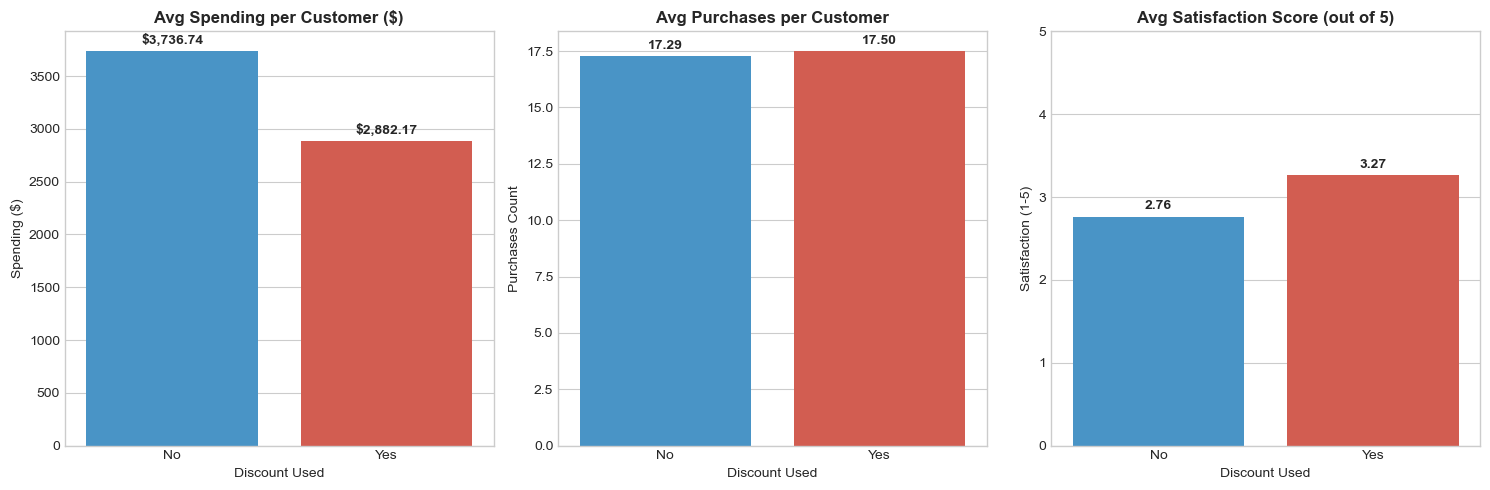

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Average Spending per Customer
sns.barplot(
    data=discount_stats, 
    x='discount_used', 
    y='avg_spending_per_customer', 
    hue='discount_used', 
    palette=['#3498db', '#e74c3c'], 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Avg Spending per Customer ($)', fontweight='bold')
axes[0].set_xlabel('Discount Used')
axes[0].set_ylabel('Spending ($)')

for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():,.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Plot 2: Average Purchase Count per Customer
sns.barplot(
    data=discount_stats, 
    x='discount_used', 
    y='avg_purchase_count', 
    hue='discount_used', 
    palette=['#3498db', '#e74c3c'], 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Avg Purchases per Customer', fontweight='bold')
axes[1].set_xlabel('Discount Used')
axes[1].set_ylabel('Purchases Count')

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Plot 3: Average Satisfaction Score
sns.barplot(
    data=discount_stats, 
    x='discount_used', 
    y='avg_satisfaction', 
    hue='discount_used', 
    palette=['#3498db', '#e74c3c'], 
    legend=False, 
    ax=axes[2]
)
axes[2].set_title('Avg Satisfaction Score (out of 5)', fontweight='bold')
axes[2].set_xlabel('Discount Used')
axes[2].set_ylabel('Satisfaction (1-5)')
axes[2].set_ylim(0, 5)

for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()